In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, chi2_contingency, entropy, pointbiserialr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.metrics import mean_squared_error
from scipy.stats import chi2_contingency
from Scripts.metrics import test_onehot_fields, test_categorical_fields, test_numerical_fields, analyze_onehot_correlations, analyze_categorical_correlations, compare_correlation_between_num_fields_and_cat


In [3]:
ONEHOT_FIELDS = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 
                'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
CATEGORICAL_FIELDS = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
NUMERICAL_FIELDS = ['AMOUNT_EQ', 'EXCHANGE_RATA']
real_data = pd.read_csv('Data/Sber/Clear/transact_1.csv')  # Реальные данные
synth_data = pd.read_csv('Data/Sber/Clear/transact_V1.csv')

In [4]:
len(real_data)

275259

In [5]:
len(synth_data)

275259


ANALYSIS FOR: PaymentSystem


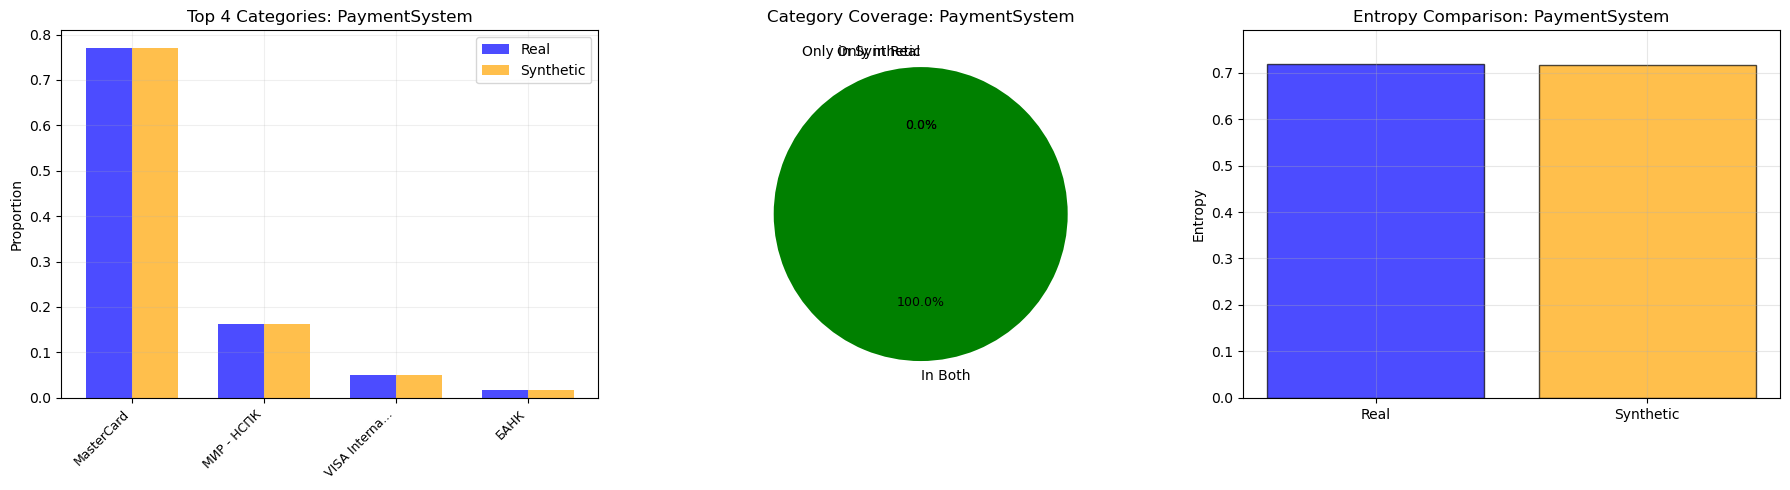

Unique values: Real=4, Synthetic=4
Category coverage: 100.0%
Chi-square test: p-value = 0.6235 (Similar)
Entropy: Real=0.719, Synthetic=0.717
Top 3 real categories: ['MasterCard', 'МИР - НСПК', 'VISA International']
Top 3 synth categories: ['MasterCard', 'МИР - НСПК', 'VISA International']

ANALYSIS FOR: OpType


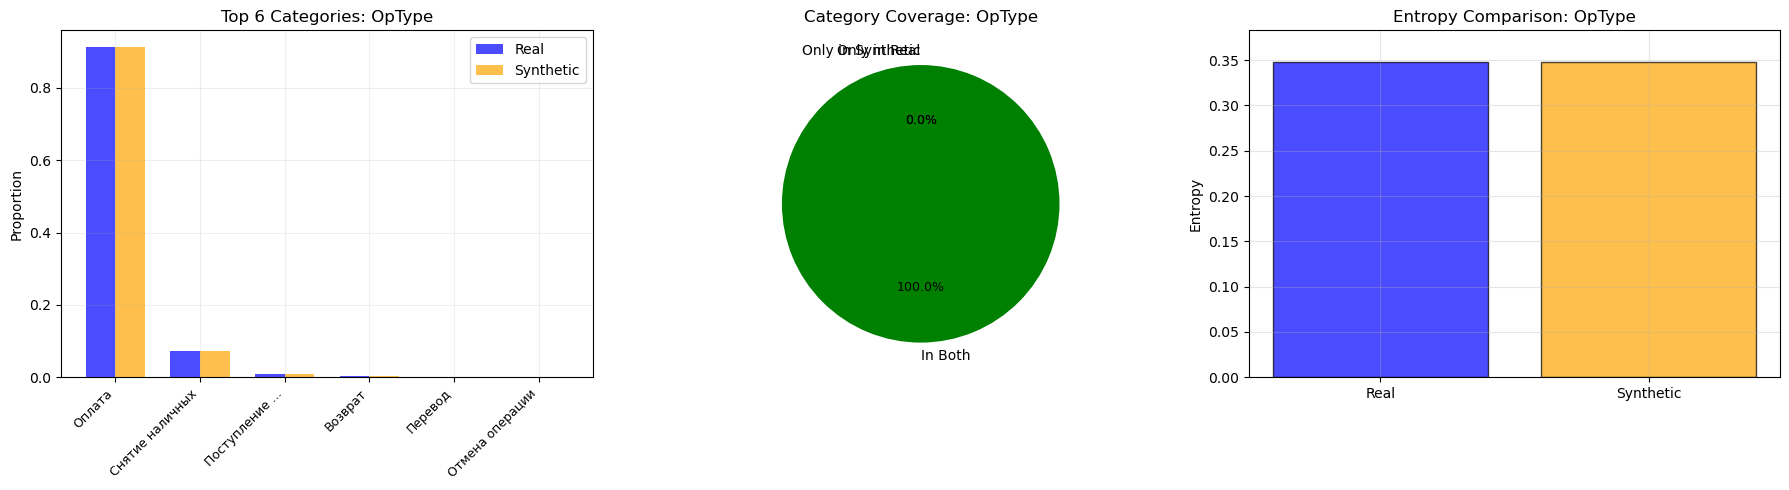

Unique values: Real=6, Synthetic=6
Category coverage: 100.0%
Chi-square test: p-value = 0.9450 (Similar)
Entropy: Real=0.348, Synthetic=0.348
Top 3 real categories: ['Оплата', 'Снятие наличных', 'Поступление средств']
Top 3 synth categories: ['Оплата', 'Снятие наличных', 'Поступление средств']

ANALYSIS FOR: DETAILEDCARDTYPE


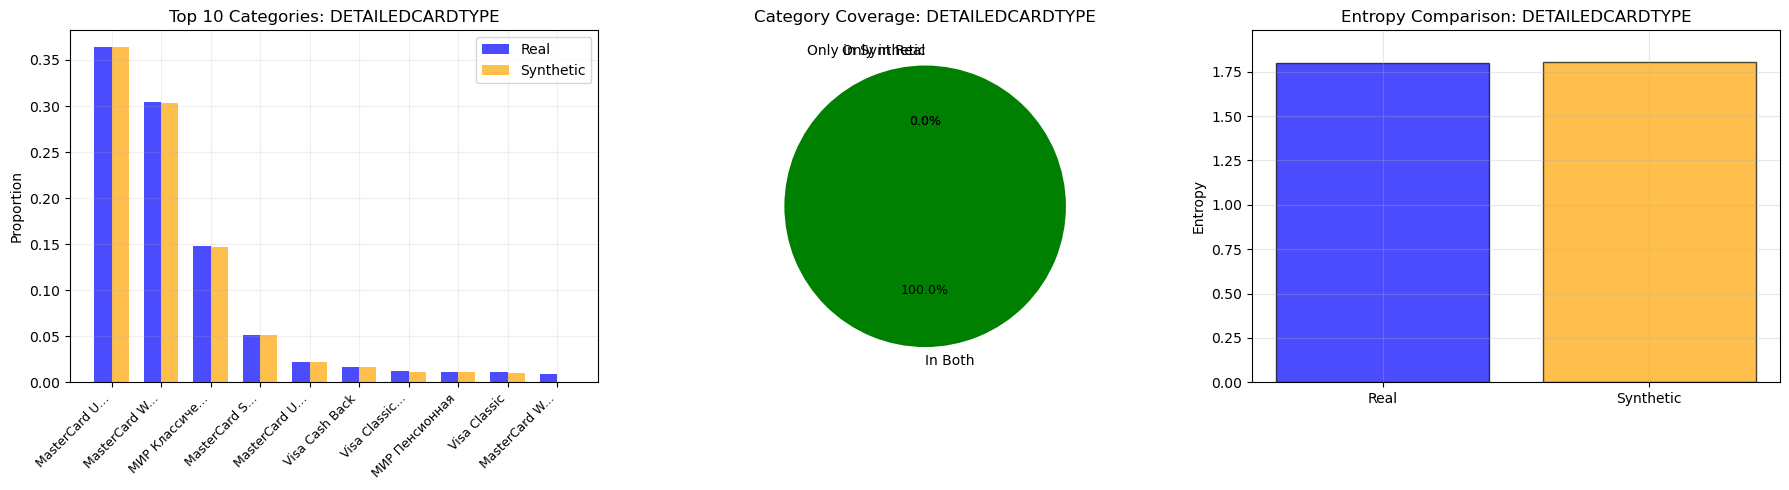

Unique values: Real=30, Synthetic=30
Category coverage: 100.0%
Chi-square test: p-value = 0.0000 (Different)
Entropy: Real=1.801, Synthetic=1.803
Top 3 real categories: ['MasterCard Unembo...', 'MasterCard World', 'МИР Классическая ...']
Top 3 synth categories: ['MasterCard Unembo...', 'MasterCard World', 'МИР Классическая ...']

ANALYSIS FOR: TRANMETHOD


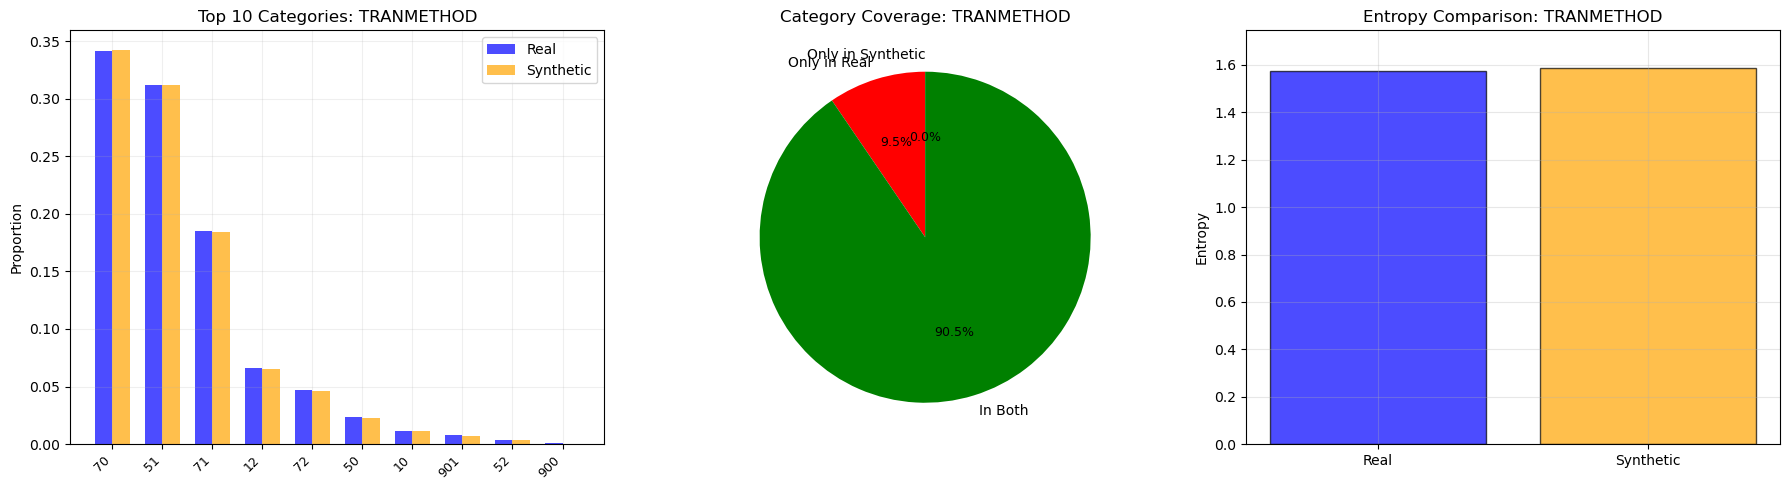

Unique values: Real=21, Synthetic=19
Category coverage: 90.5%
Chi-square test: p-value = 0.0000 (Different)
Entropy: Real=1.575, Synthetic=1.587
Top 3 real categories: ['70', '51', '71']
Top 3 synth categories: ['70', '51', '71']

ANALYSIS FOR: ISOWNTERMINAL


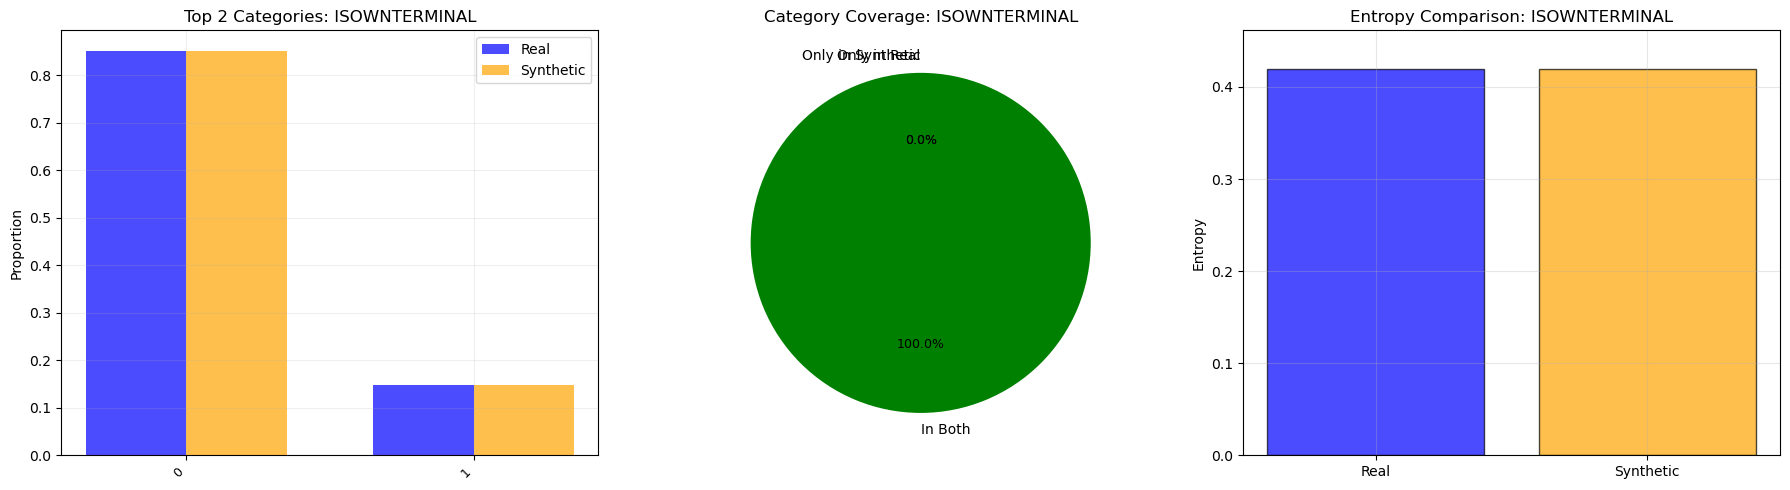

Unique values: Real=2, Synthetic=2
Category coverage: 100.0%
Chi-square test: p-value = 0.8644 (Similar)
Entropy: Real=0.419, Synthetic=0.419
Top 3 real categories: ['0', '1']
Top 3 synth categories: ['0', '1']

ANALYSIS FOR: NAME


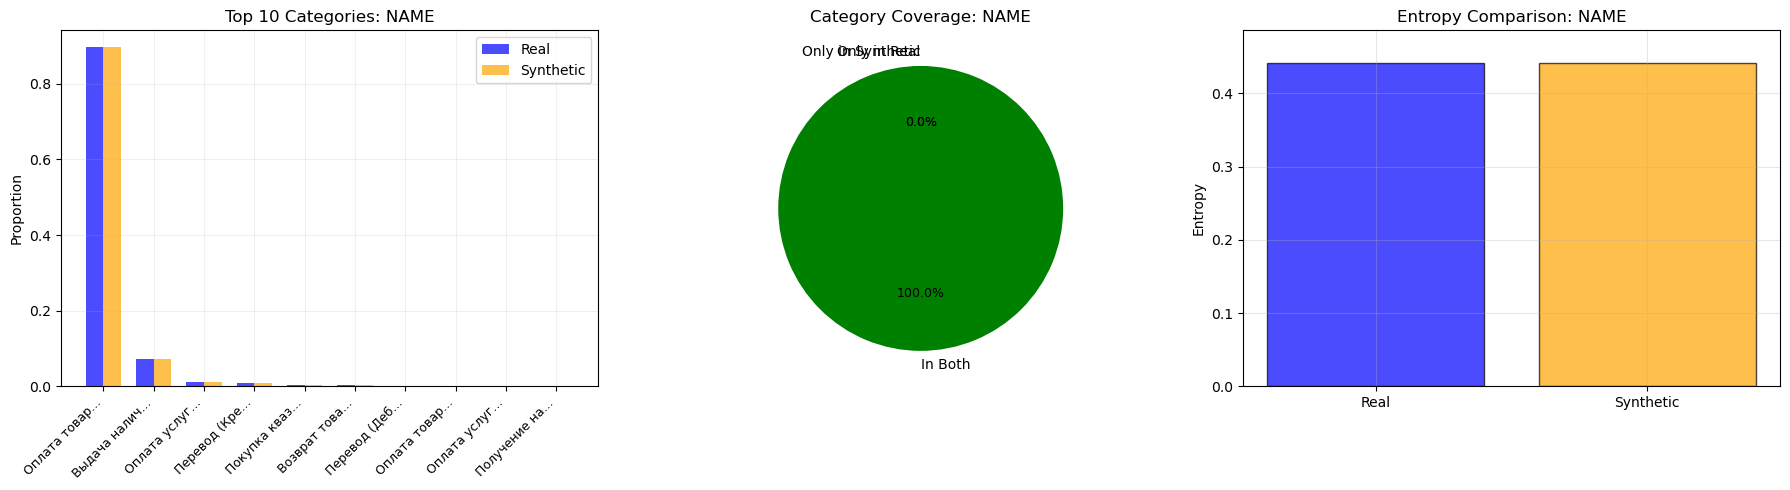

Unique values: Real=12, Synthetic=12
Category coverage: 100.0%
Chi-square test: p-value = 0.0000 (Different)
Entropy: Real=0.441, Synthetic=0.442
Top 3 real categories: ['Оплата товаров/ус...', 'Выдача наличных д...', 'Оплата услуг чере...']
Top 3 synth categories: ['Оплата товаров/ус...', 'Выдача наличных д...', 'Оплата услуг чере...']

ANALYSIS FOR: MCC


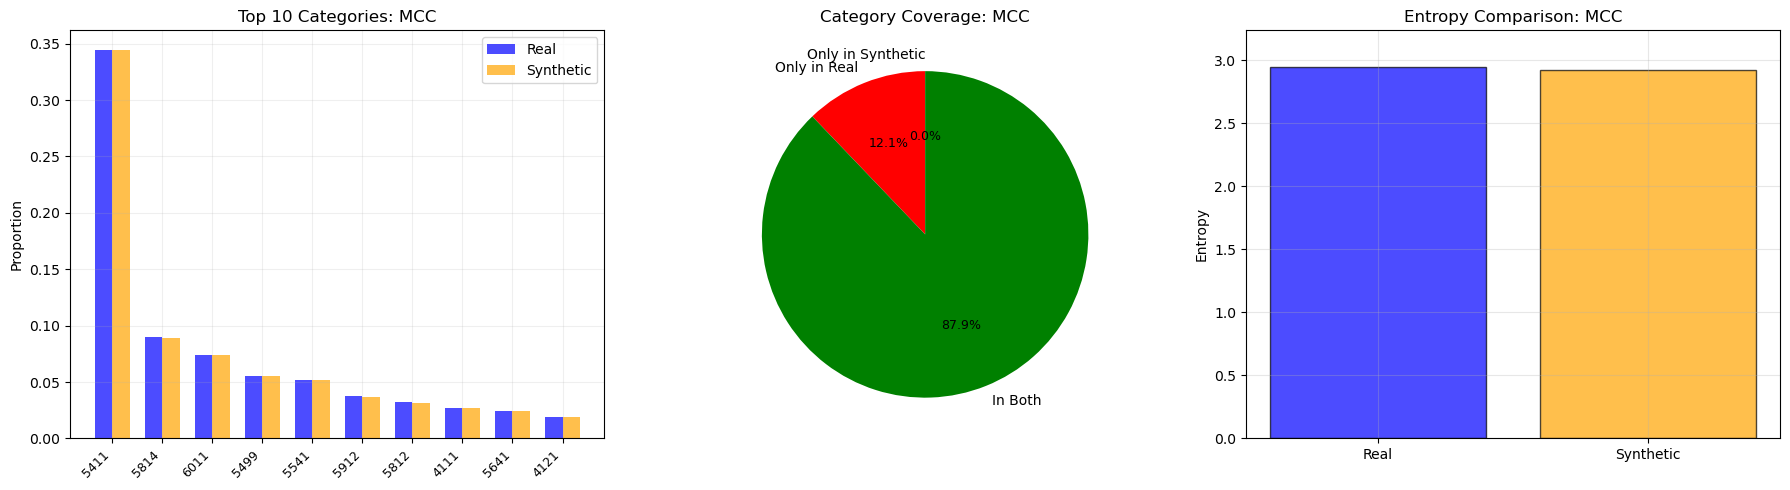

Unique values: Real=247, Synthetic=217
Category coverage: 87.9%
Chi-square test: p-value = 0.0000 (Different)
Entropy: Real=2.941, Synthetic=2.924
Top 3 real categories: ['5411', '5814', '6011']
Top 3 synth categories: ['5411', '5814', '6011']

ANALYSIS FOR: DEVICETYPE


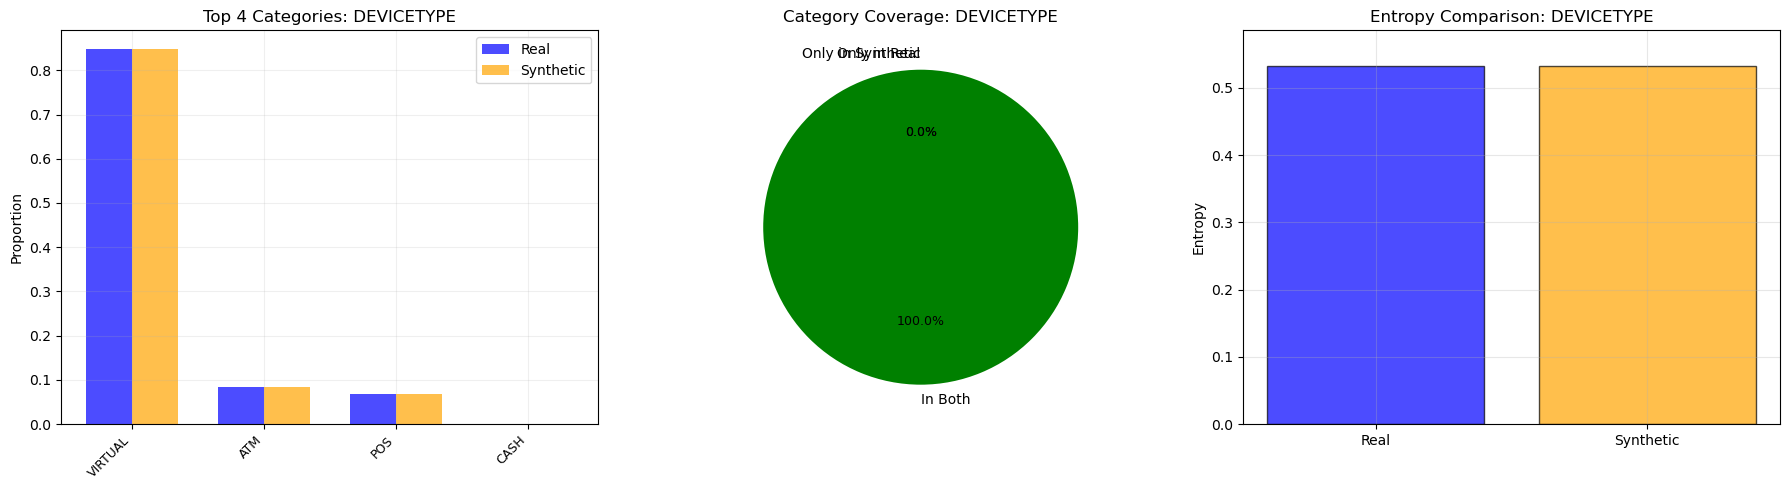

Unique values: Real=4, Synthetic=4
Category coverage: 100.0%
Chi-square test: p-value = 0.9964 (Similar)
Entropy: Real=0.532, Synthetic=0.532
Top 3 real categories: ['VIRTUAL', 'ATM', 'POS']
Top 3 synth categories: ['VIRTUAL', 'ATM', 'POS']

ANALYSIS FOR: CurrencyName


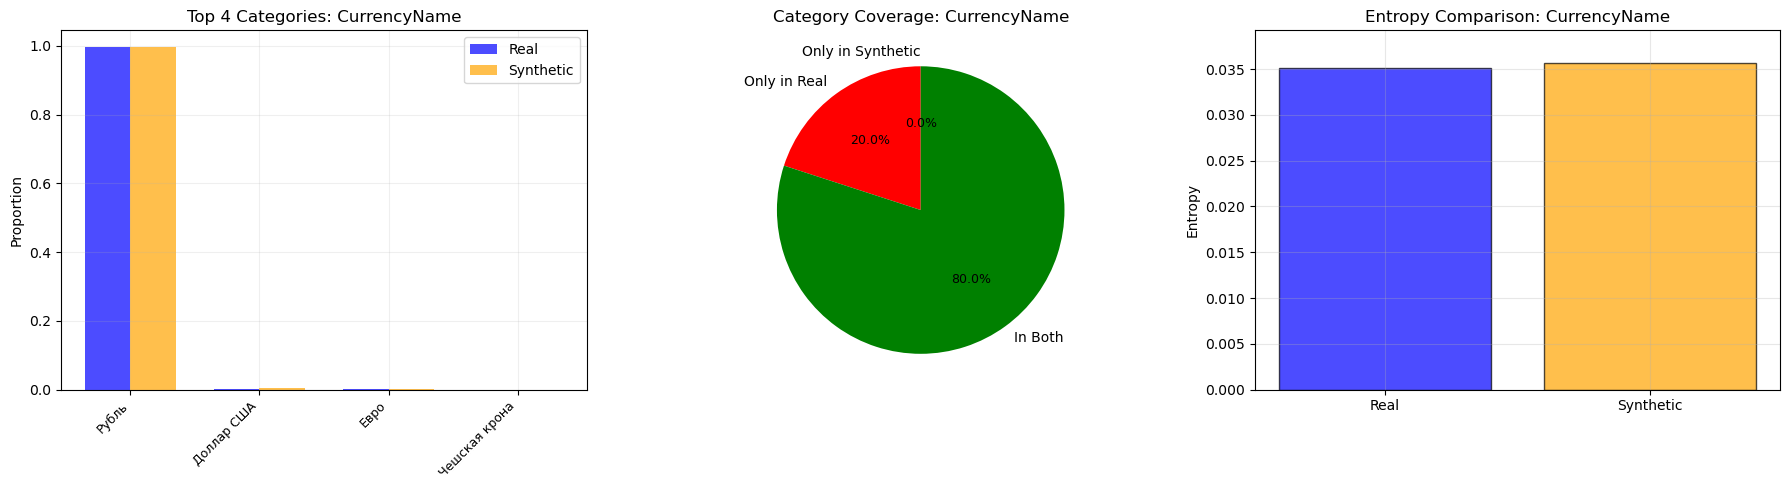

Unique values: Real=5, Synthetic=4
Category coverage: 80.0%
Chi-square test: p-value = 0.0221 (Different)
Entropy: Real=0.035, Synthetic=0.036
Top 3 real categories: ['Рубль', 'Доллар США', 'Евро']
Top 3 synth categories: ['Рубль', 'Доллар США', 'Евро']

ANALYSIS FOR: CITY


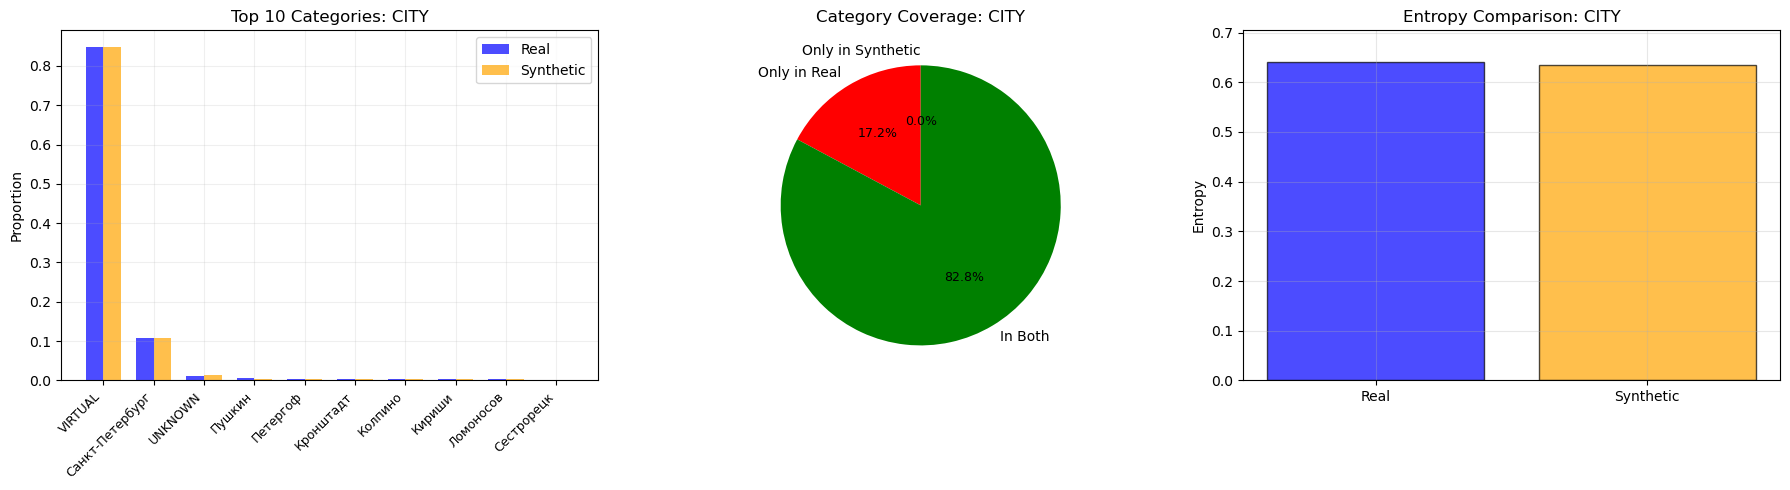

Unique values: Real=64, Synthetic=53
Category coverage: 82.8%
Chi-square test: p-value = 0.0000 (Different)
Entropy: Real=0.640, Synthetic=0.635
Top 3 real categories: ['VIRTUAL', 'Санкт-Петербург', 'UNKNOWN']
Top 3 synth categories: ['VIRTUAL', 'Санкт-Петербург', 'UNKNOWN']

ANALYSIS FOR: REGION


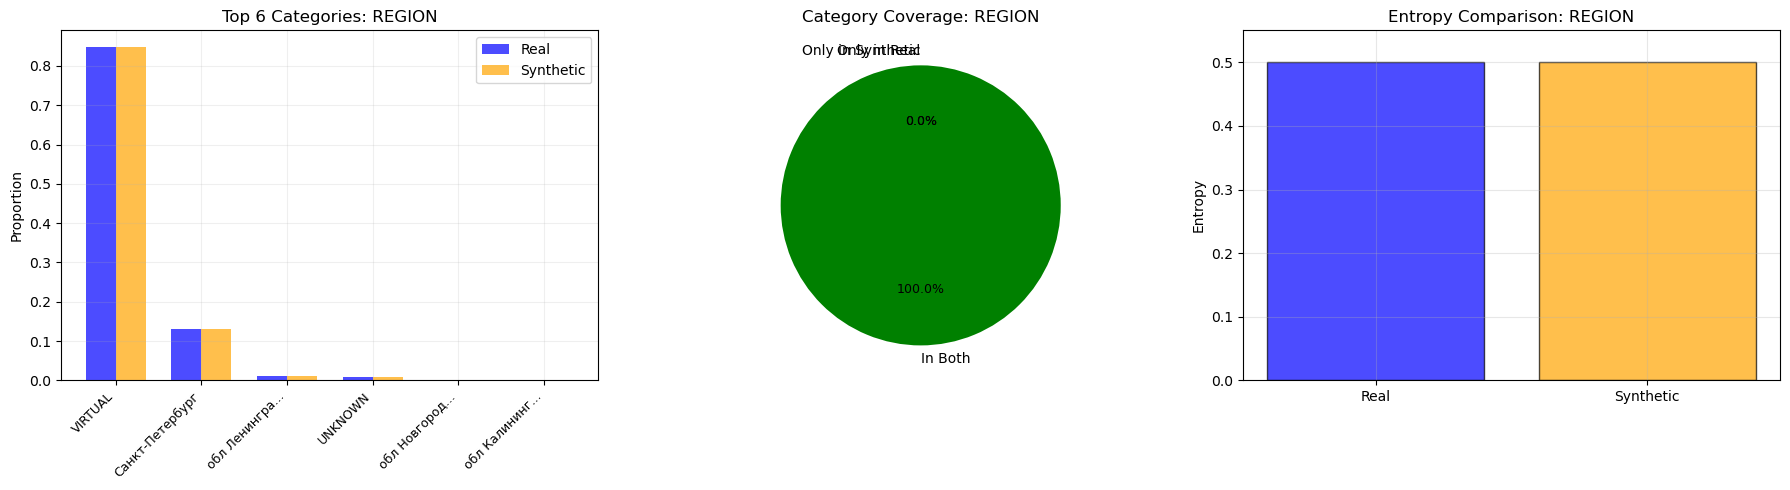

Unique values: Real=6, Synthetic=6
Category coverage: 100.0%
Chi-square test: p-value = 0.3610 (Similar)
Entropy: Real=0.500, Synthetic=0.500
Top 3 real categories: ['VIRTUAL', 'Санкт-Петербург', 'обл Ленинградская']
Top 3 synth categories: ['VIRTUAL', 'Санкт-Петербург', 'обл Ленинградская']

ANALYSIS FOR: ISVIRTUALTRANSACTION


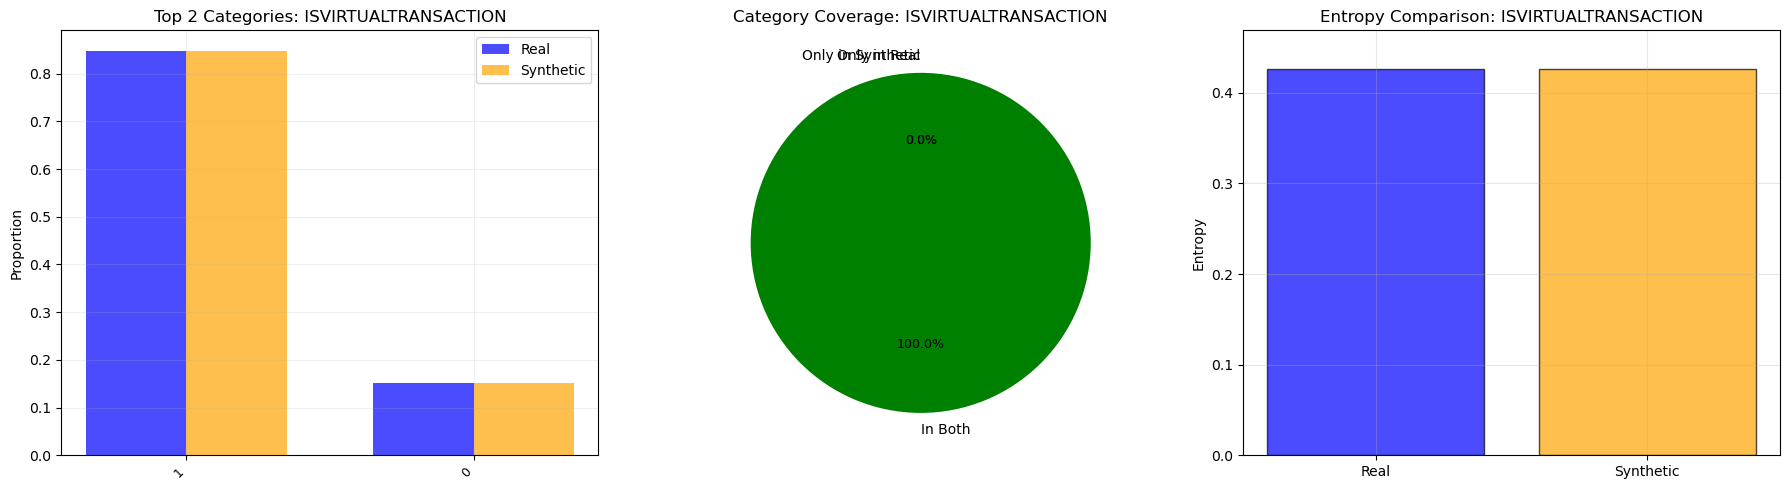

Unique values: Real=2, Synthetic=2
Category coverage: 100.0%
Chi-square test: p-value = 0.9312 (Similar)
Entropy: Real=0.426, Synthetic=0.426
Top 3 real categories: ['1', '0']
Top 3 synth categories: ['1', '0']


In [4]:
test_onehot_fields(real_data, synth_data, ONEHOT_FIELDS)


HIGH CARDINALITY ANALYSIS: ACCOUNT_ID


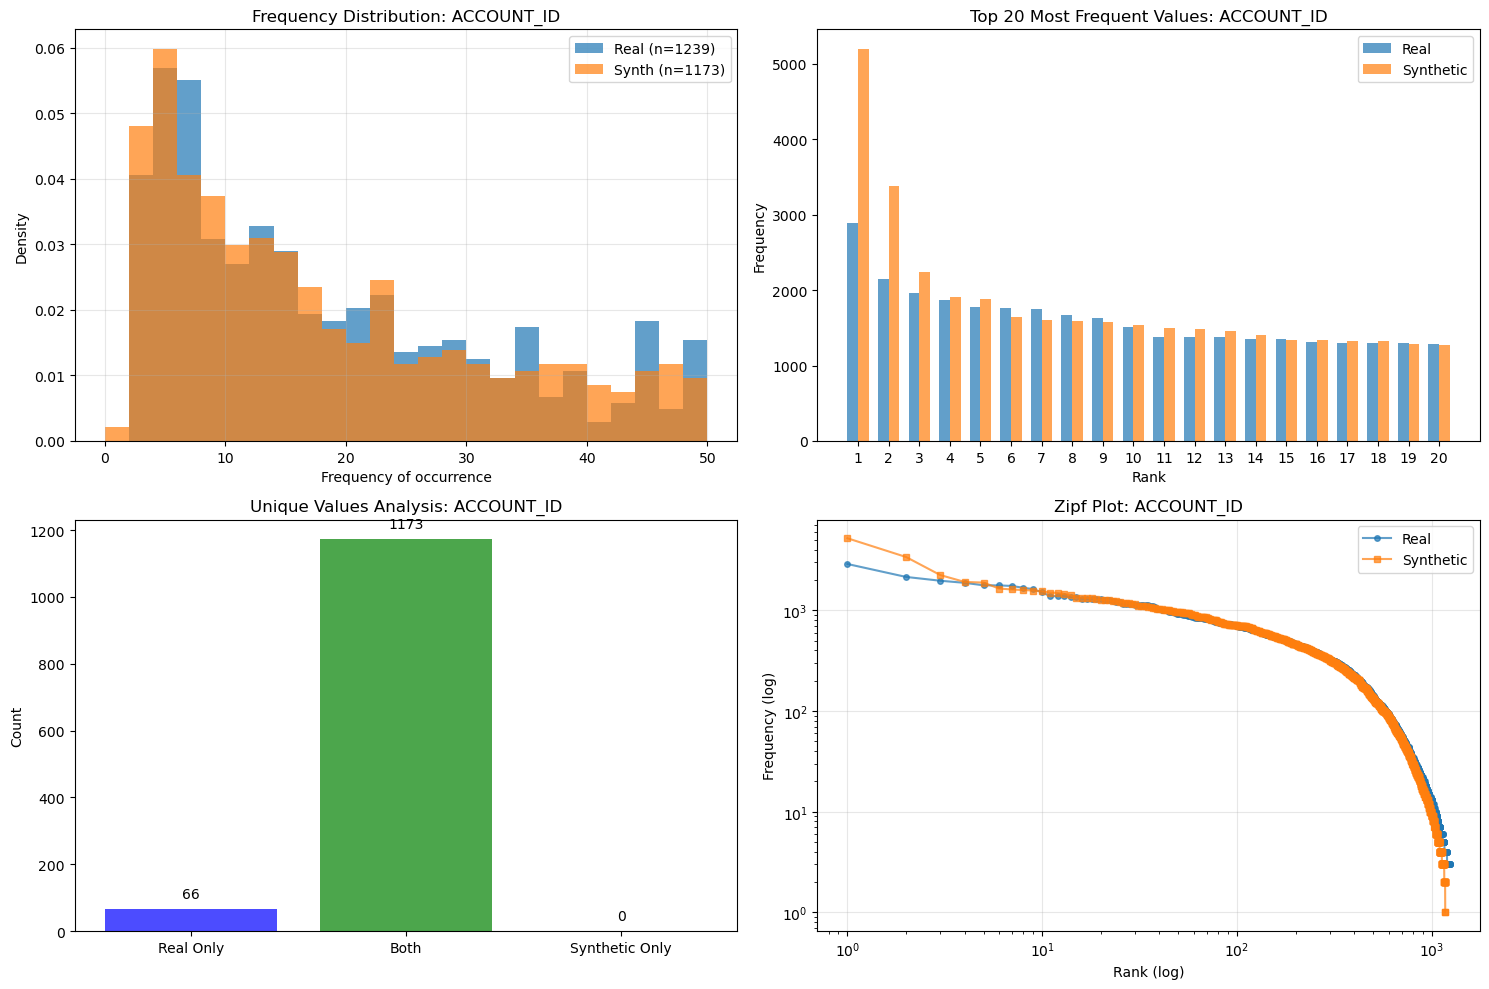

Unique values: Real=1,239, Synthetic=1,173
Overlap: 1,173 values (94.7% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=222.16, Synthetic=234.66

HIGH CARDINALITY ANALYSIS: TERMINAL_CODE


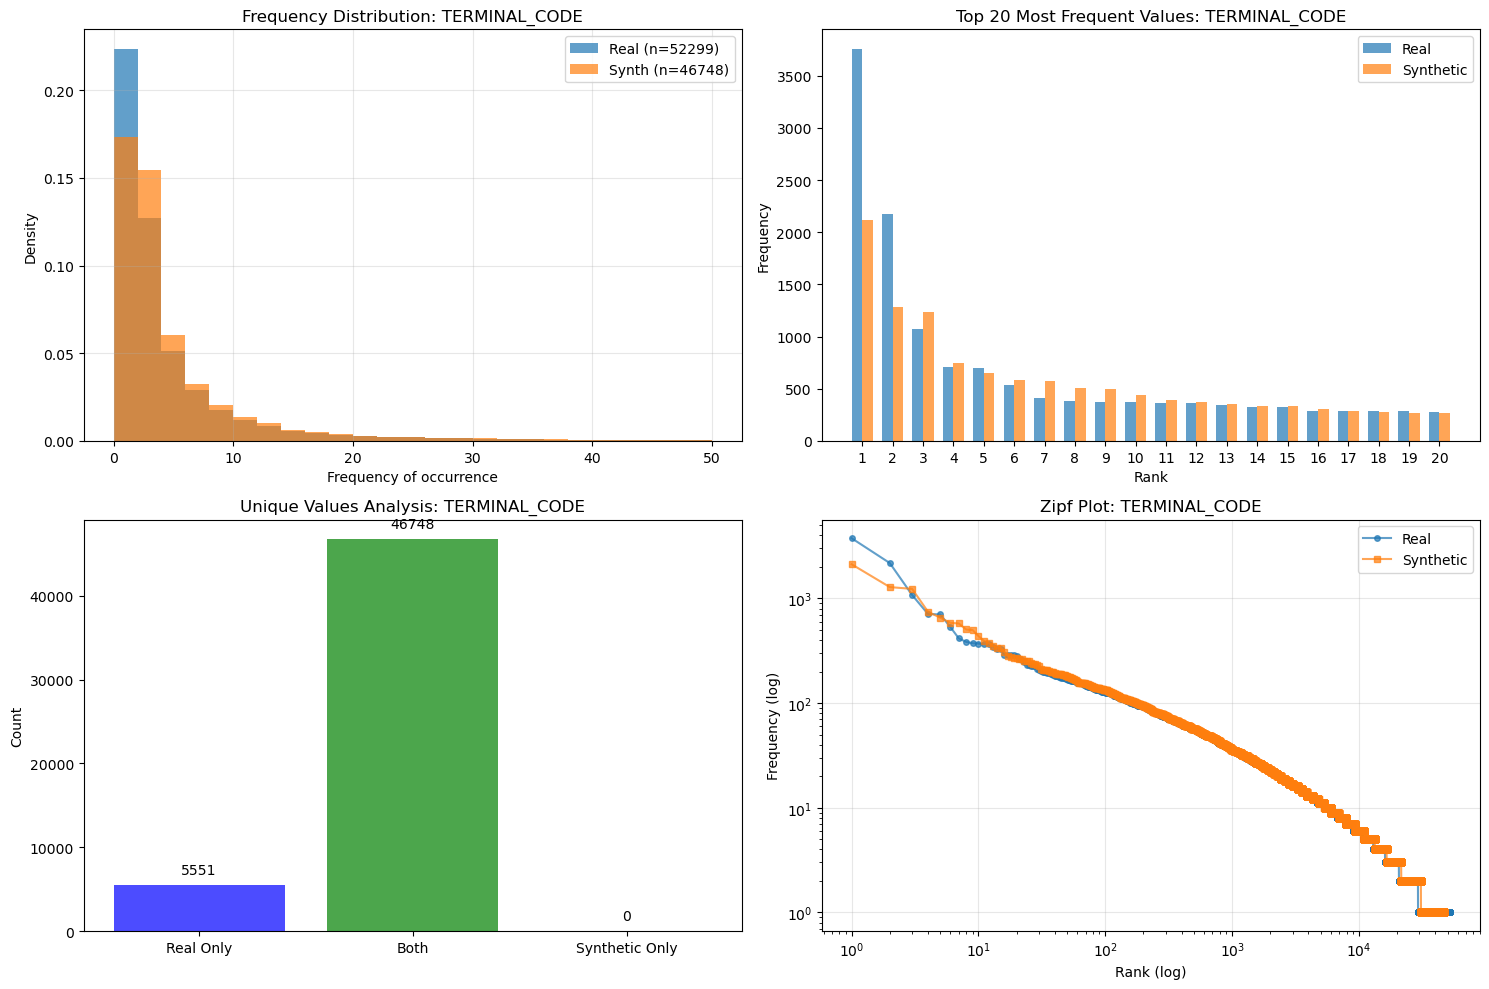

Unique values: Real=52,299, Synthetic=46,748
Overlap: 46,748 values (89.4% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=5.26, Synthetic=5.89

HIGH CARDINALITY ANALYSIS: CARD


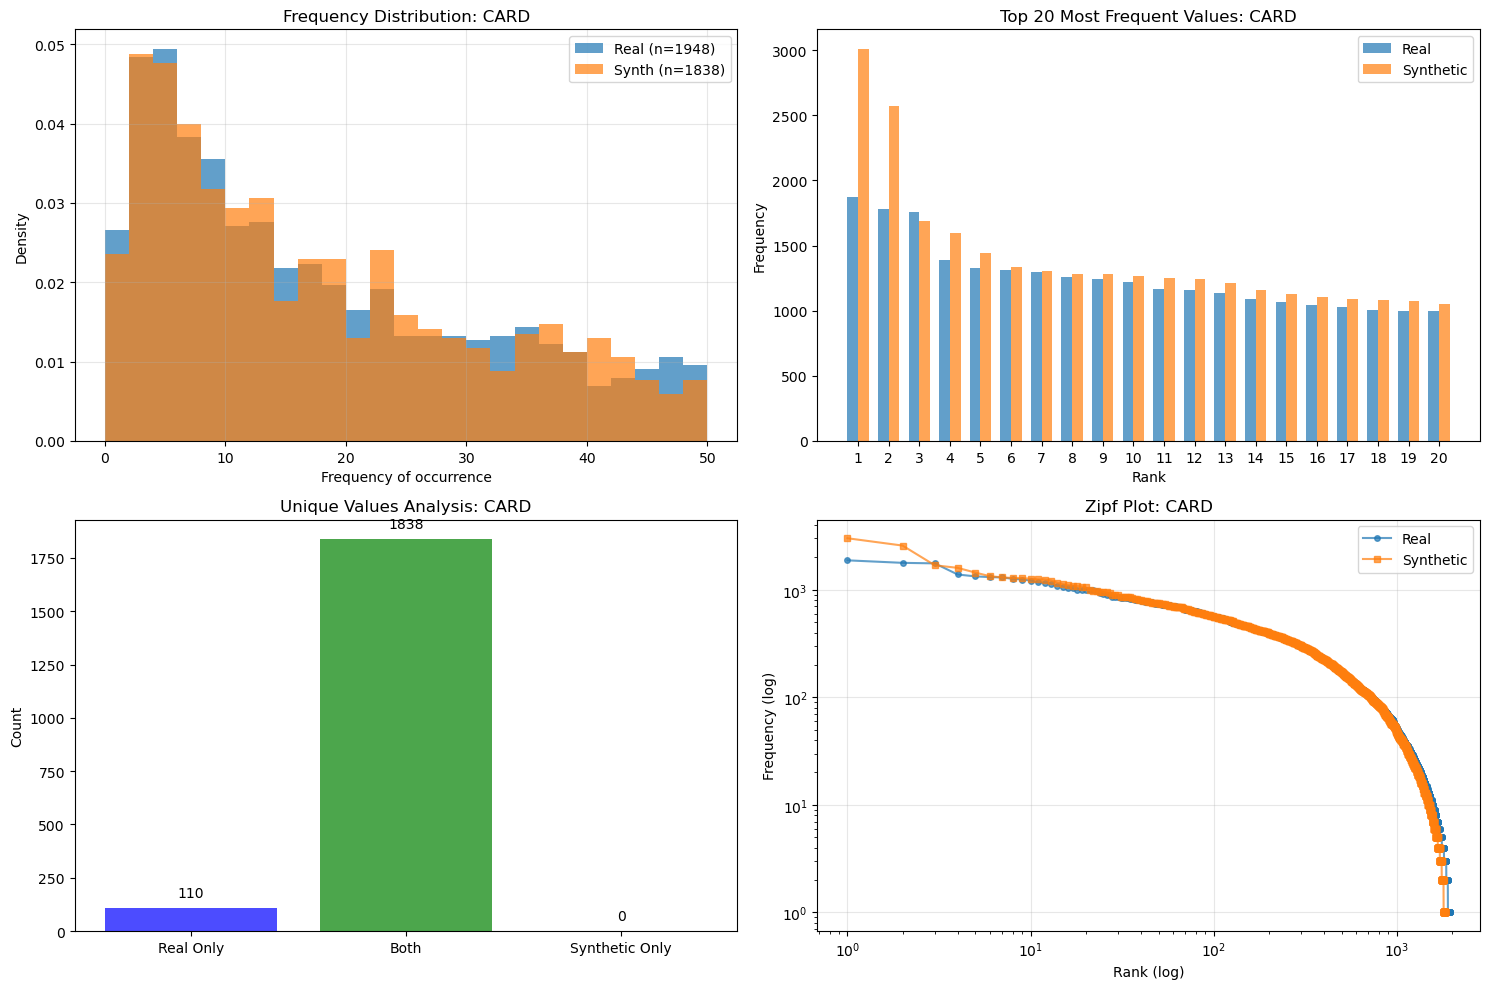

Unique values: Real=1,948, Synthetic=1,838
Overlap: 1,838 values (94.4% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=141.30, Synthetic=149.76

HIGH CARDINALITY ANALYSIS: TRANS_DETAIL


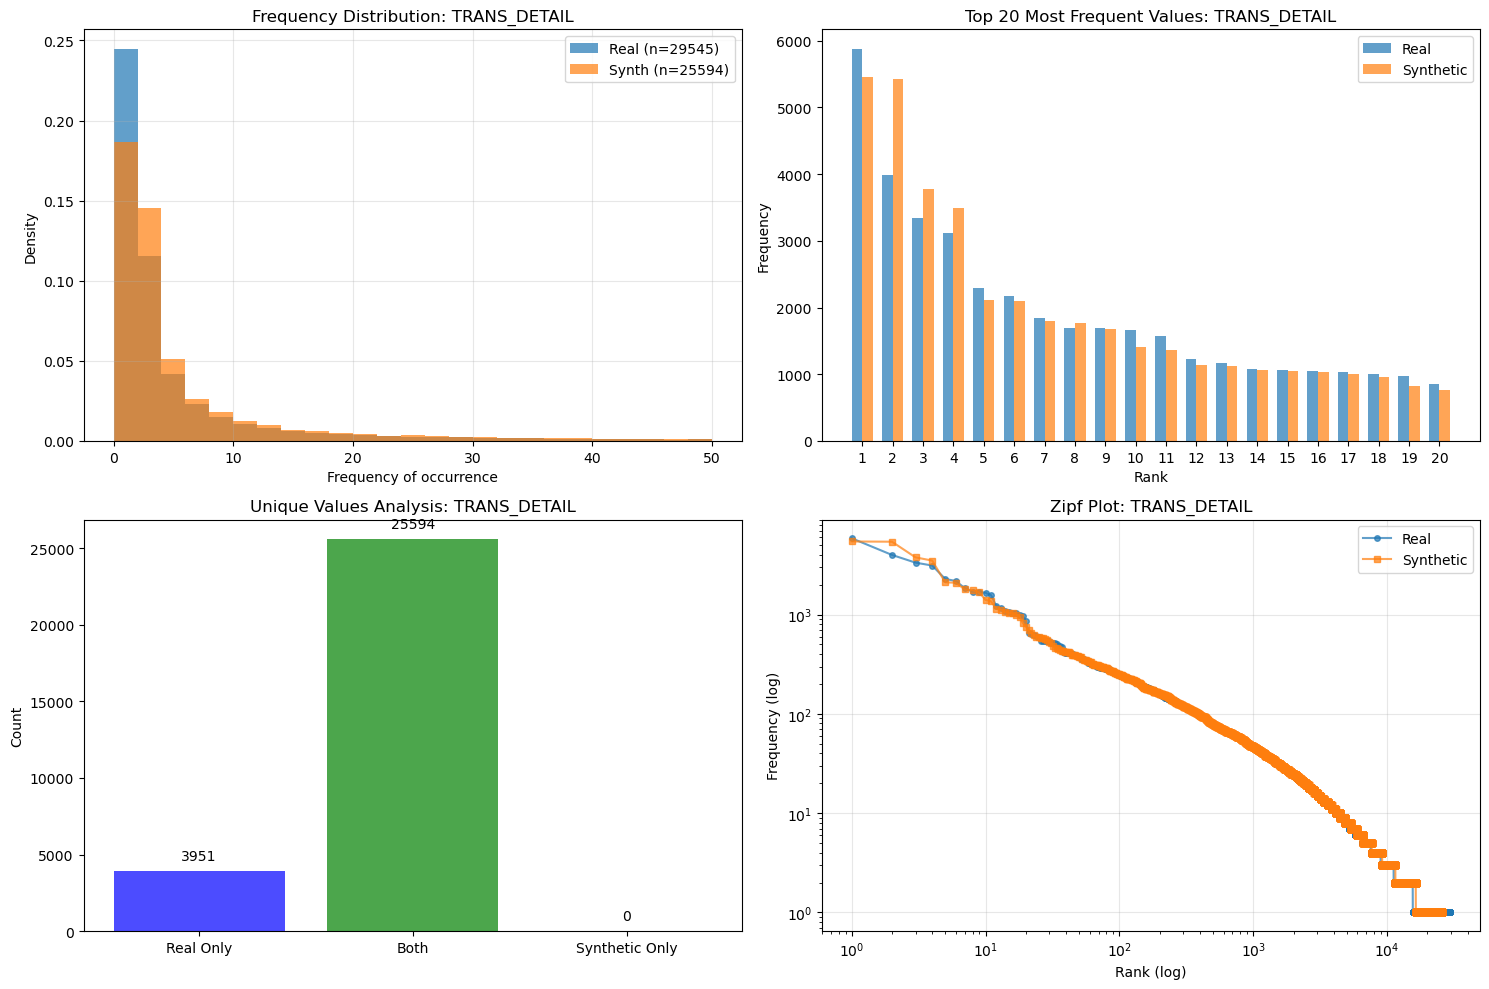

Unique values: Real=29,545, Synthetic=25,594
Overlap: 25,594 values (86.6% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=9.32, Synthetic=10.75


In [5]:
test_categorical_fields(real_data, synth_data, CATEGORICAL_FIELDS)



NUMERICAL ANALYSIS: AMOUNT_EQ


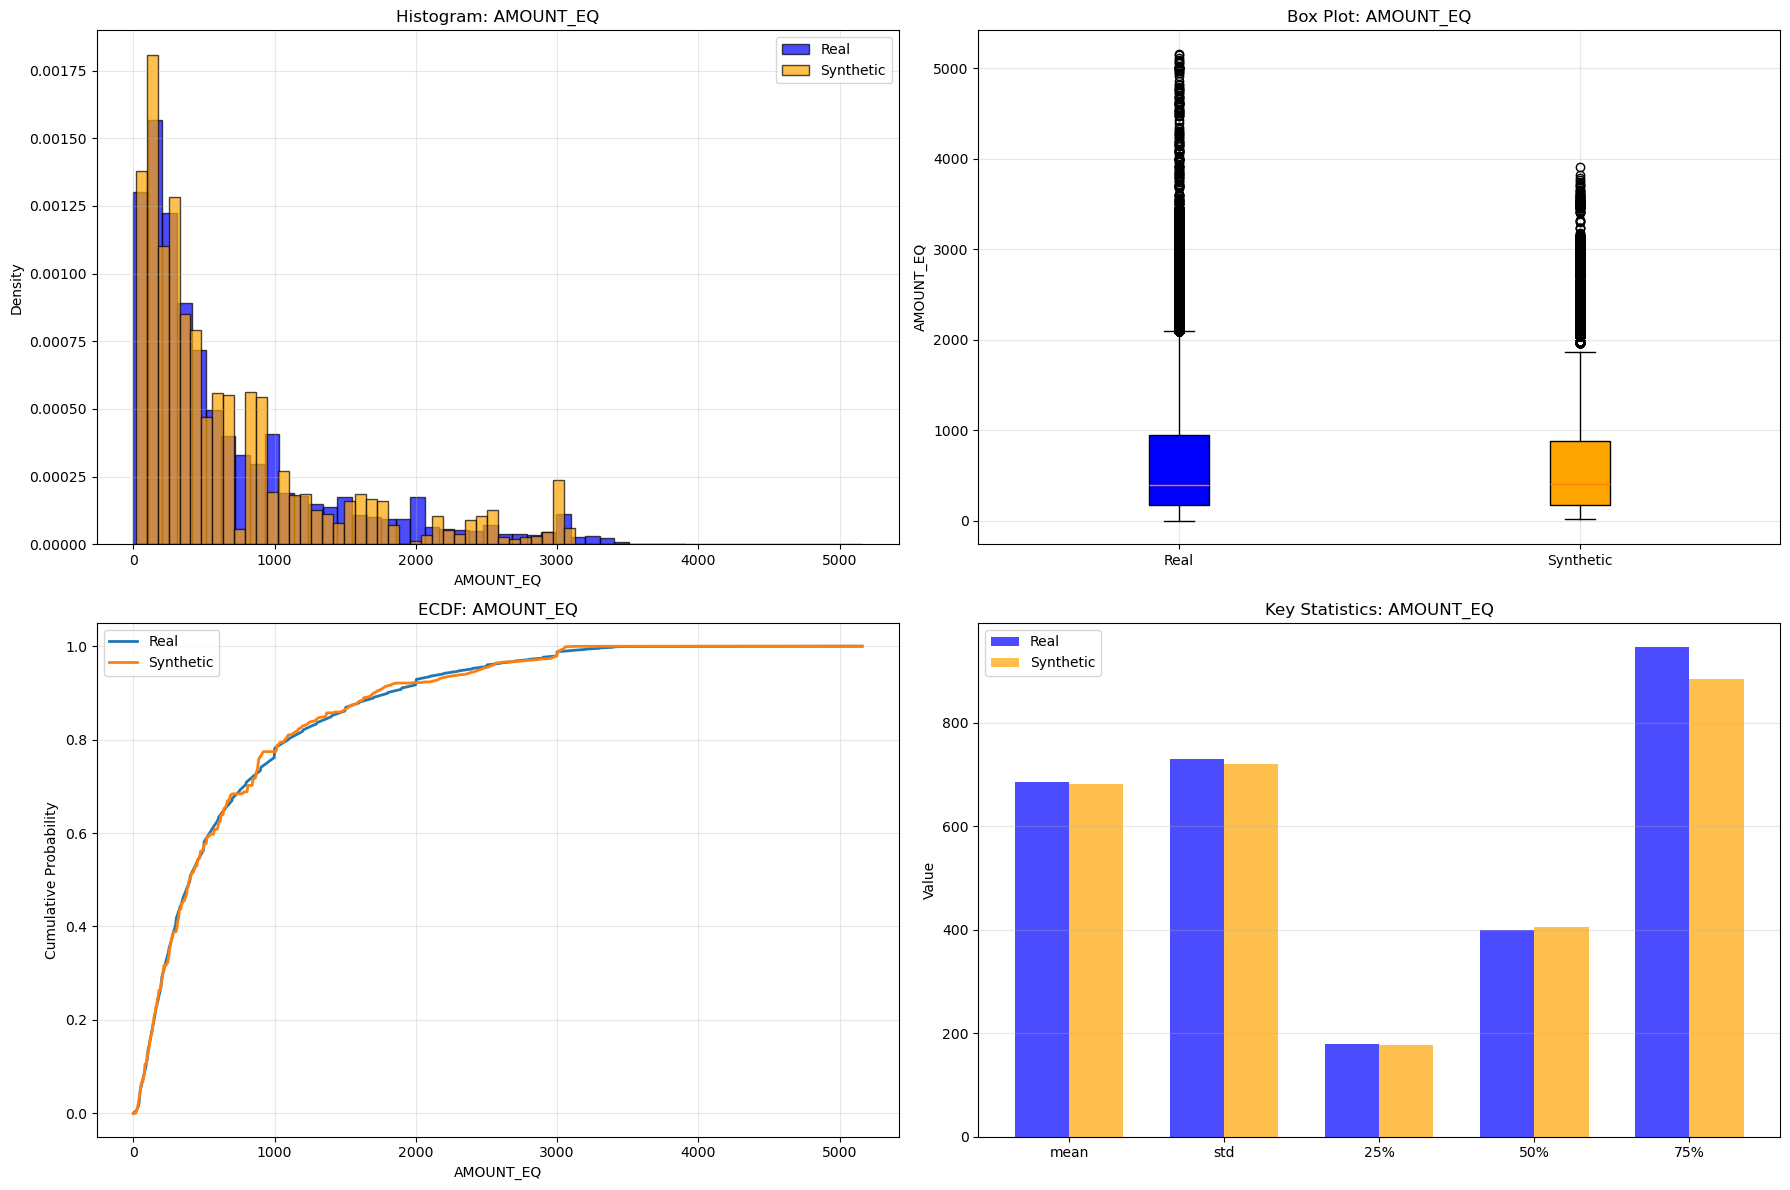

KS Test: statistic=0.0320, p-value=0.0000
Wasserstein Distance: 24.4252
Mean difference: 0.7%
Std difference: 1.2%
Median difference: 1.3%

Basic Statistics:
            count     mean      std    min     25%     50%     75%     max  \
Real       275259  685.463  729.506   0.01  180.00  400.00  946.00  5160.0   
Synthetic  275259  680.846  720.735  15.88  177.33  405.37  885.47  3903.3   

           skewness  kurtosis  
Real          1.692     2.471  
Synthetic     1.681     2.272  

NUMERICAL ANALYSIS: EXCHANGE_RATA


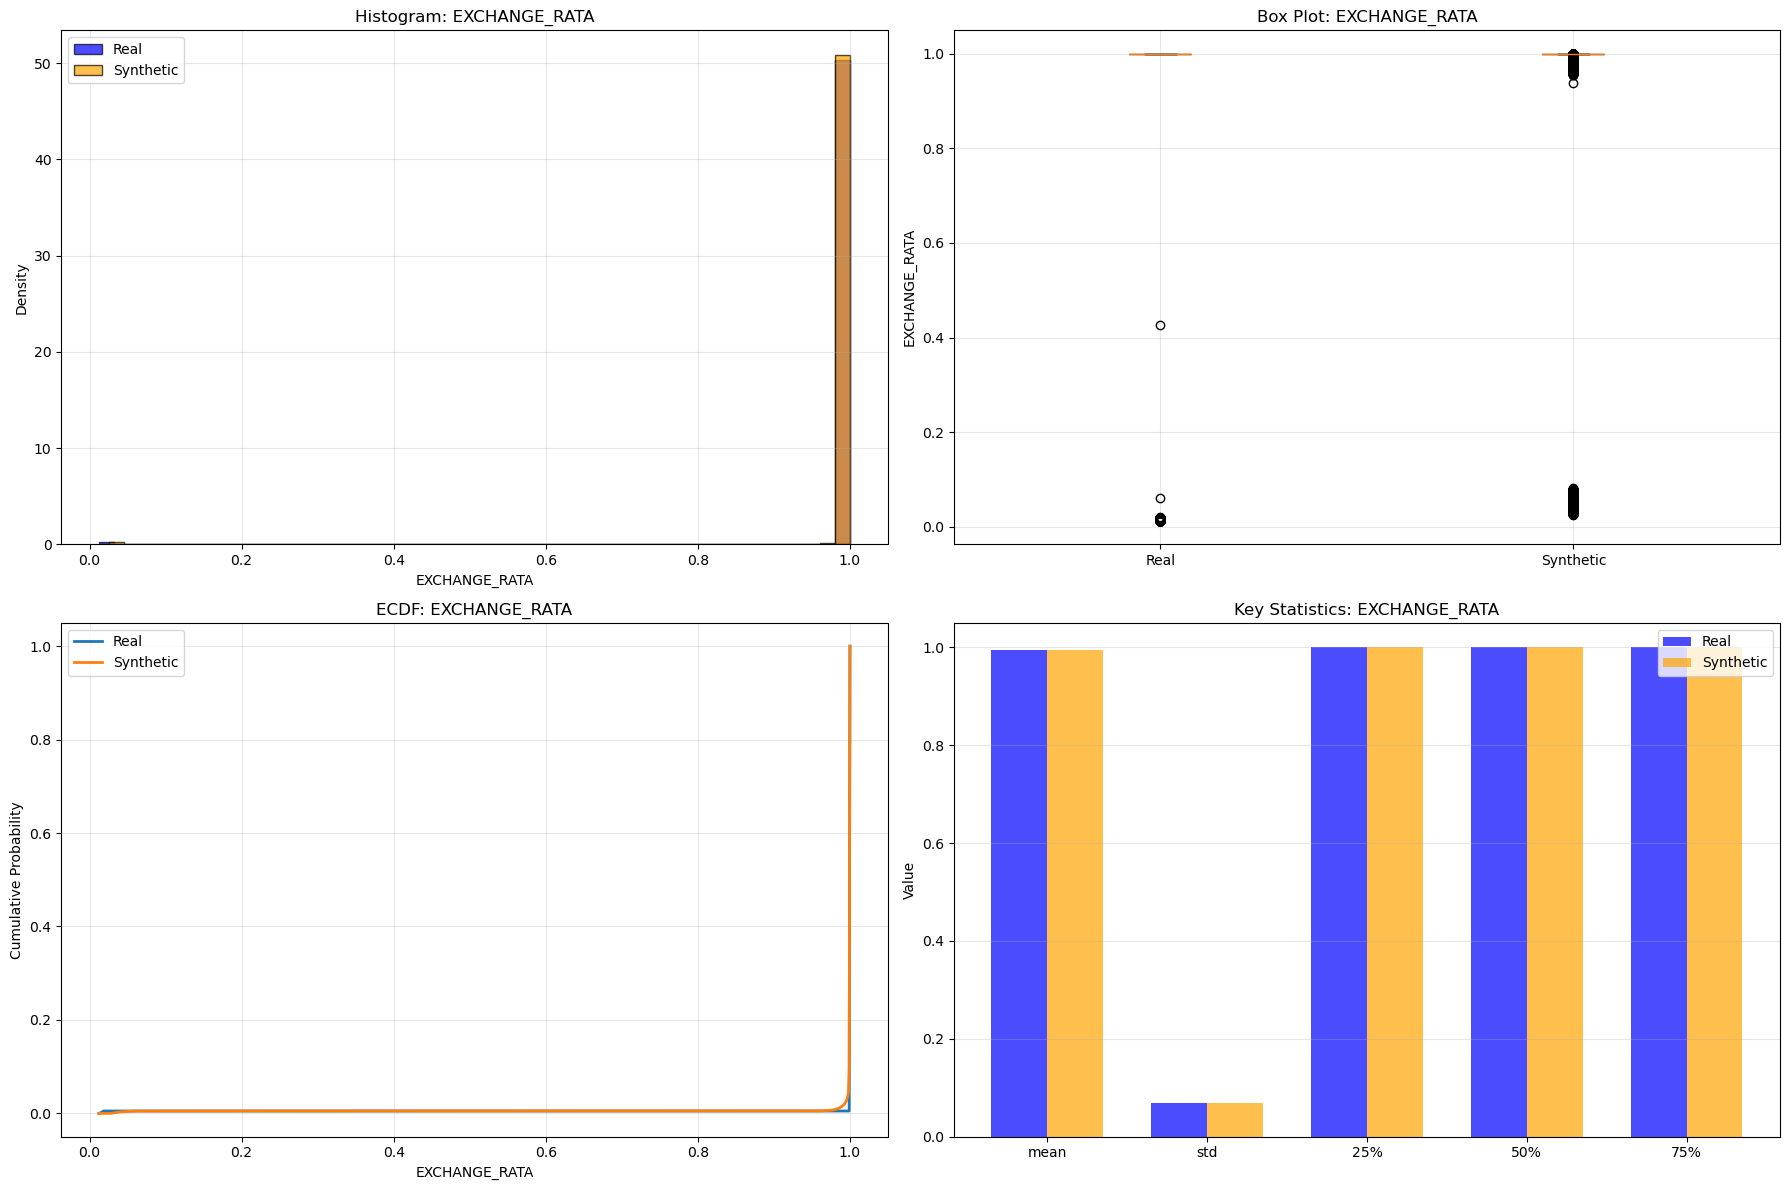

KS Test: statistic=0.9621, p-value=0.0000
Wasserstein Distance: 0.0006
Mean difference: 0.0%
Std difference: 2.5%
Median difference: 0.0%

Basic Statistics:
            count   mean    std    min  25%  50%  75%  max  skewness  kurtosis
Real       275259  0.995  0.070  0.012  1.0  1.0  1.0  1.0   -13.947   192.534
Synthetic  275259  0.995  0.068  0.026  1.0  1.0  1.0  1.0   -13.932   192.318


In [6]:
test_numerical_fields(real_data, synth_data, NUMERICAL_FIELDS)


CORRELATION ANALYSIS CATEGORICAL FIELDS

1. Categorical Feature


  Mean absolute difference (Cramér's V): 0.3503
  Max absolute difference (Cramér's V): 0.3743
  Cramér's V preservation score: 0.650


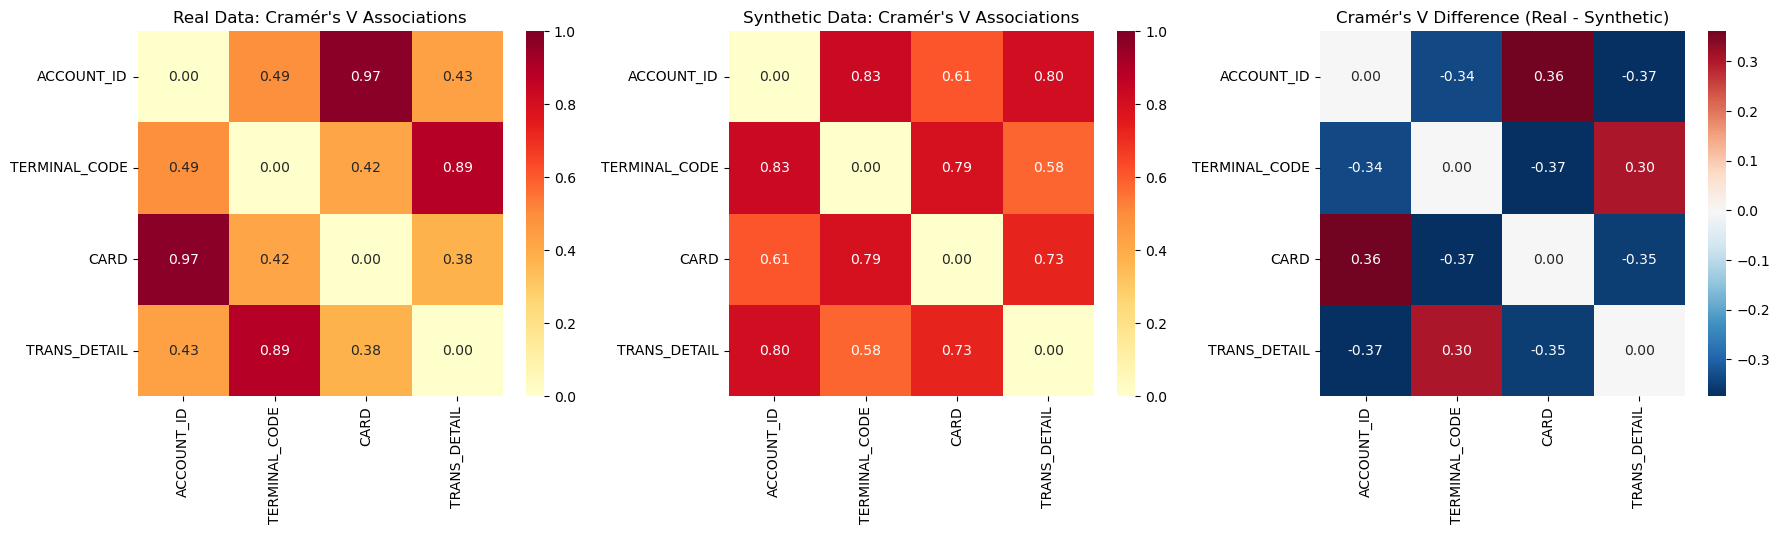

In [7]:
analyze_categorical_correlations(real_data, synth_data, CATEGORICAL_FIELDS)


ONE-HOT FIELD CORRELATION ANALYSIS
Available one-hot fields: 12

1. Cramér's V Correlation Matrices for One-Hot Fields:


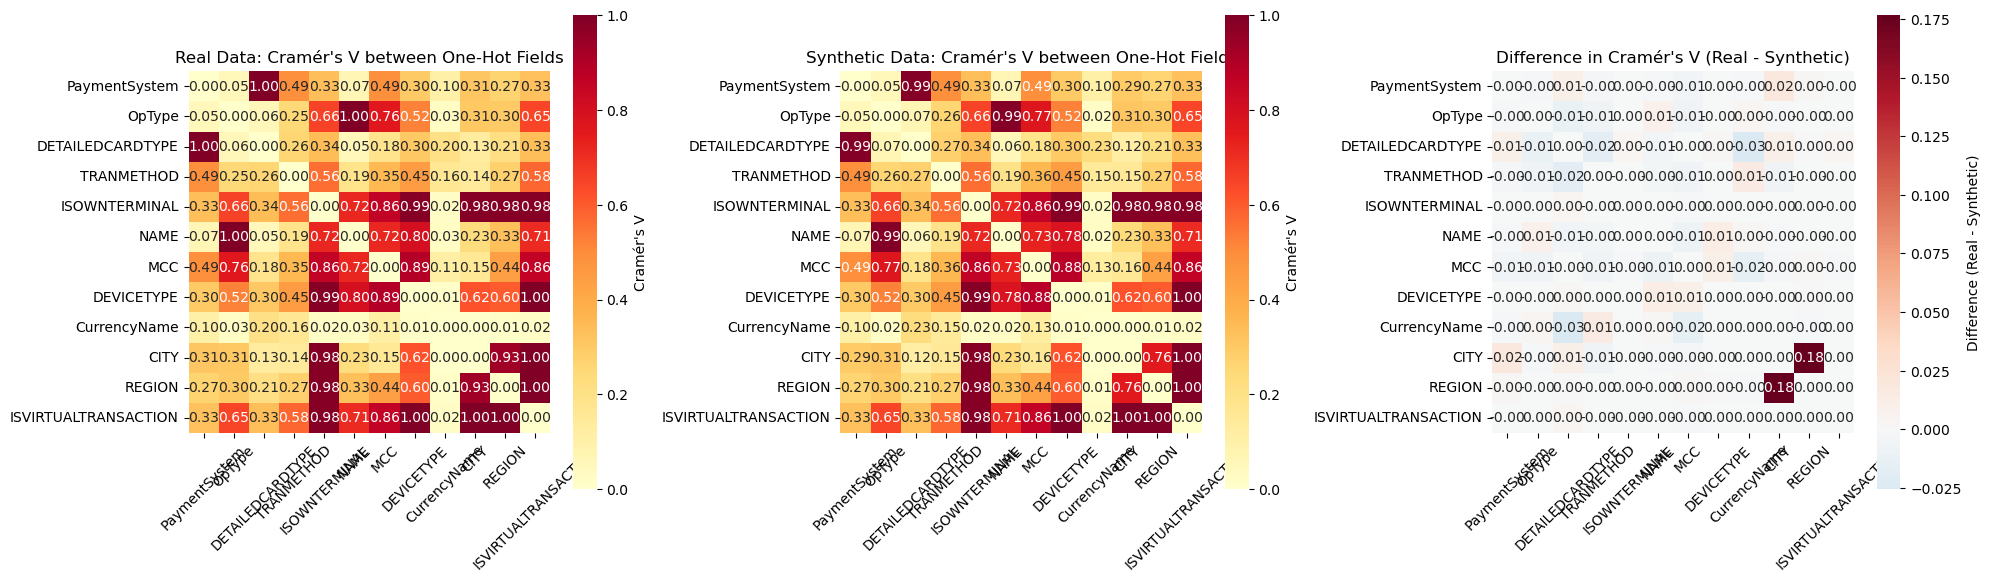


2. Correlation Difference Statistics:
   Mean absolute difference: 0.0067
   Median absolute difference: 0.0016
   Max absolute difference: 0.1767
   Std of differences: 0.0218
   Correlation preservation score: 0.993

3. Top 5 Pairs with Largest Differences:
   CITY vs REGION:
     Real Cramér's V: 0.933
     Synthetic Cramér's V: 0.756
     Difference: 0.177
   DETAILEDCARDTYPE vs CurrencyName:
     Real Cramér's V: 0.201
     Synthetic Cramér's V: 0.227
     Difference: -0.026
   PaymentSystem vs CITY:
     Real Cramér's V: 0.311
     Synthetic Cramér's V: 0.293
     Difference: 0.018
   DETAILEDCARDTYPE vs TRANMETHOD:
     Real Cramér's V: 0.256
     Synthetic Cramér's V: 0.273
     Difference: -0.018
   MCC vs CurrencyName:
     Real Cramér's V: 0.110
     Synthetic Cramér's V: 0.125
     Difference: -0.016


In [8]:
analyze_onehot_correlations(real_data, synth_data, ONEHOT_FIELDS)

In [9]:
compare_correlation_between_num_fields_and_cat(real_data, synth_data, num_field='EXCHANGE_RATA', cat_field='CurrencyName')


4. EXCHANGE_RATA vs CurrencyName Analysis:
EXCHANGE_RATA Statistics by Currency:
Currency             Real Mean    Synth Mean   Diff %    
------------------------------------------------------------
Евро                 0.0139       0.9999       7083.4    %
Доллар США           0.0168       0.9977       5834.3    %
Злотый               0.0604       0.9999       1556.8    %
Рубль                1.0000       0.9947       0.5       %
